# DEVELOPERSHUB CORPORATION

# Task 3: Customer Churn Prediction (Bank Customers) 
# Objective: 
#  Identify customers who are likely to leave the bank. 
# Dataset: 
#  Churn Modelling Dataset 
# Instructions: 
# ● Clean and prepare the dataset. 
# ● Encode categorical features such as geography and gender. 
# ● Train a classification model. 
# ● Analyze feature importance to understand what influences churn. 
# Skills: 
# ● Categorical data encoding (Label Encoding / One-Hot Encoding) 
# ● Supervised classification modeling 
# ● Understanding and interpreting feature importance

In [1]:
import pandas as pd
df = pd.read_csv('Churn_Modelling.csv')

CUSTOMER CHURN PREDICTION - DATASET OVERVIEW
Dataset shape: (10000, 14)

First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        1125

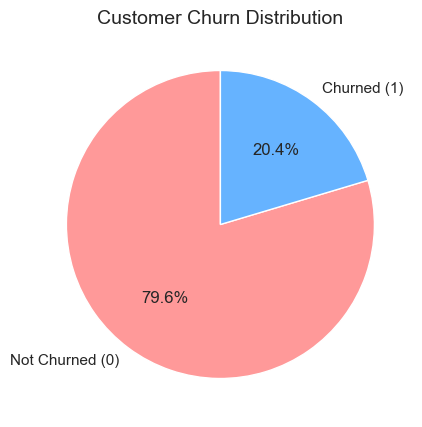


Churn Distribution:
Not Churned (0): 7963 customers (79.6%)
Churned (1): 2037 customers (20.4%)


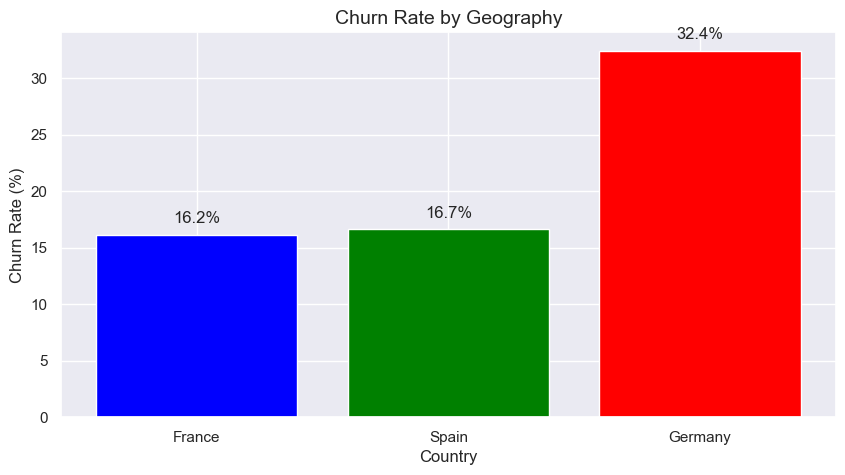

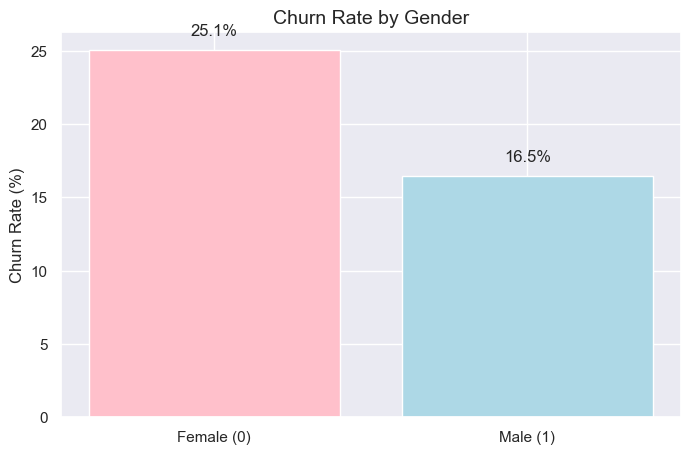

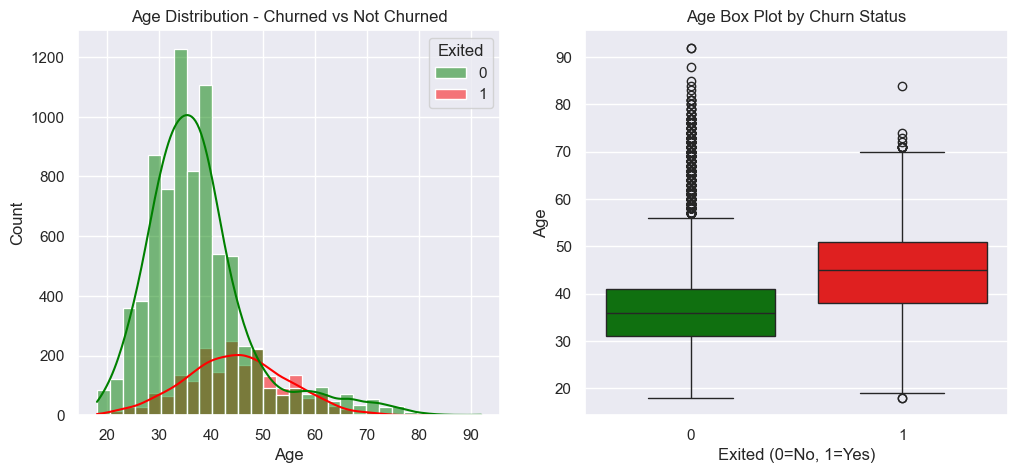

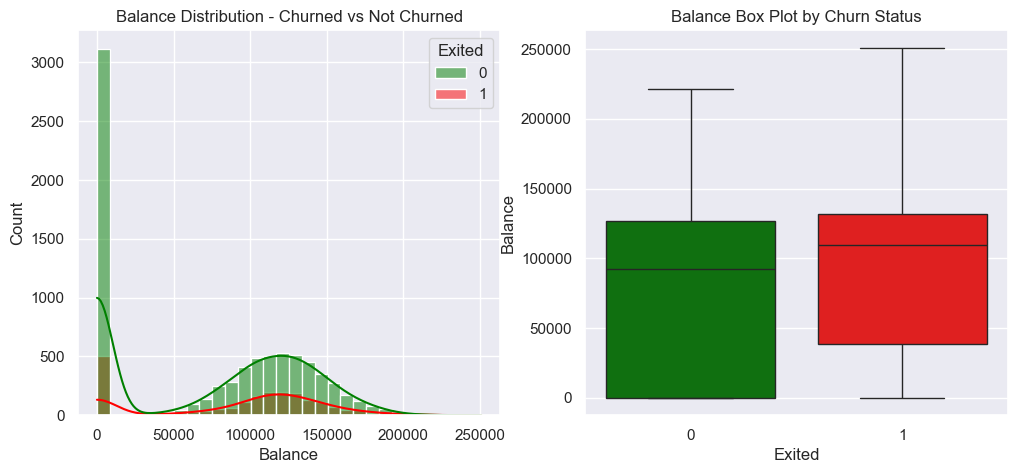

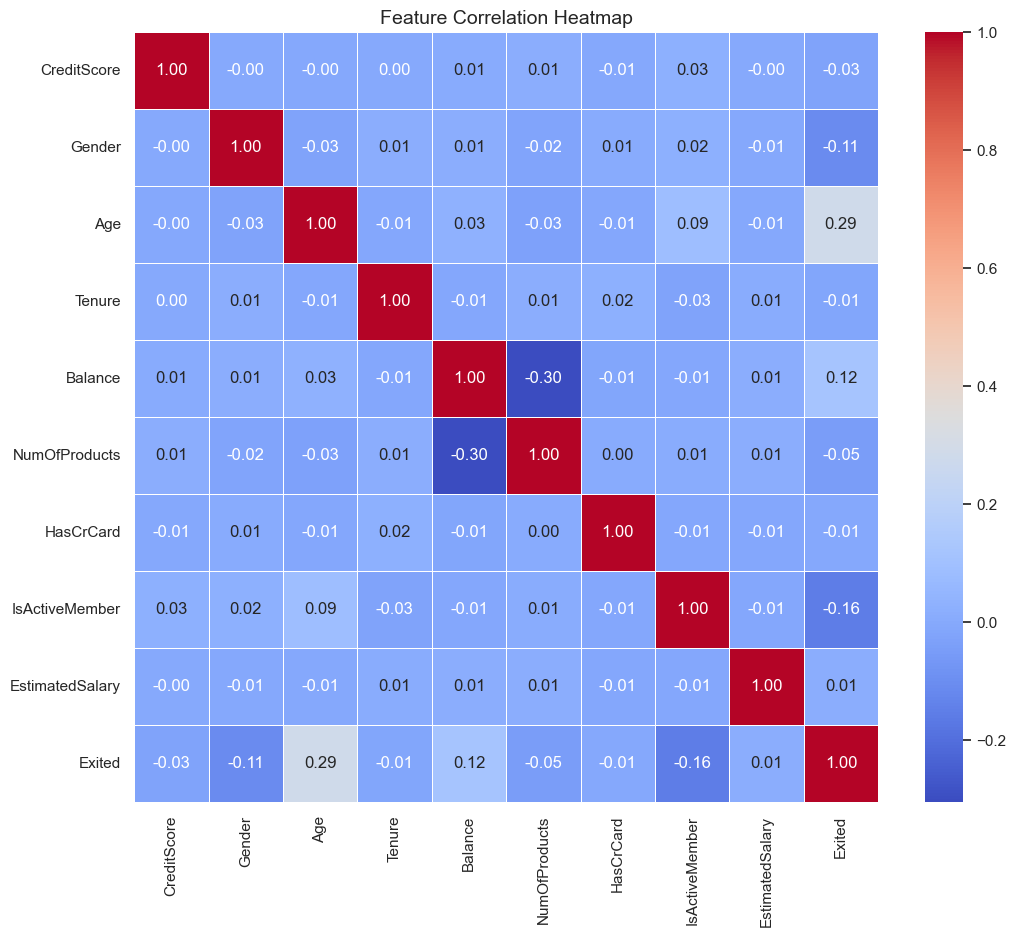


MODEL PREPARATION
Features shape: (10000, 12)
Target shape: (10000,)

Features columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geo_France', 'Geo_Germany', 'Geo_Spain']

Training set: 8000 samples
Test set: 2000 samples

MODEL TRAINING & EVALUATION

----------------------------------------
LOGISTIC REGRESSION
----------------------------------------
Accuracy: 0.8080
AUC Score: 0.7748

Confusion Matrix:
[[1540   53]
 [ 331   76]]

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


----------------------------------------
DECISION TREE
----------------------------------------
Accuracy: 0.8560
AUC Score: 0.8421



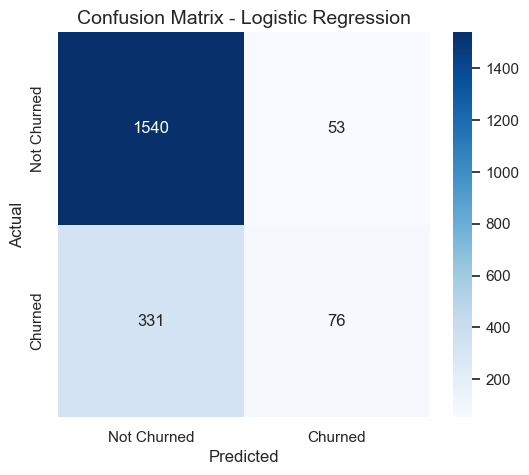

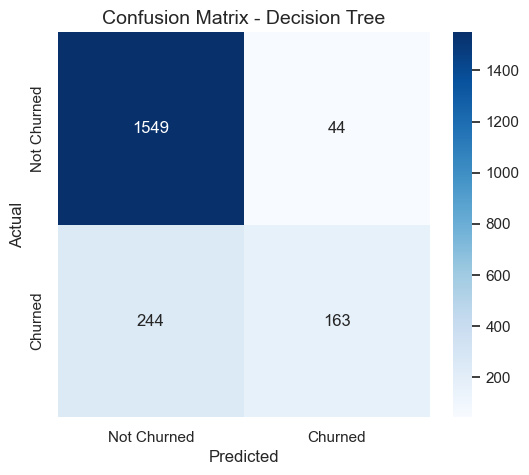

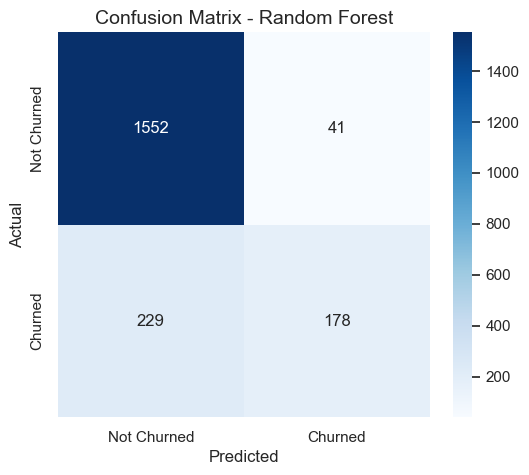

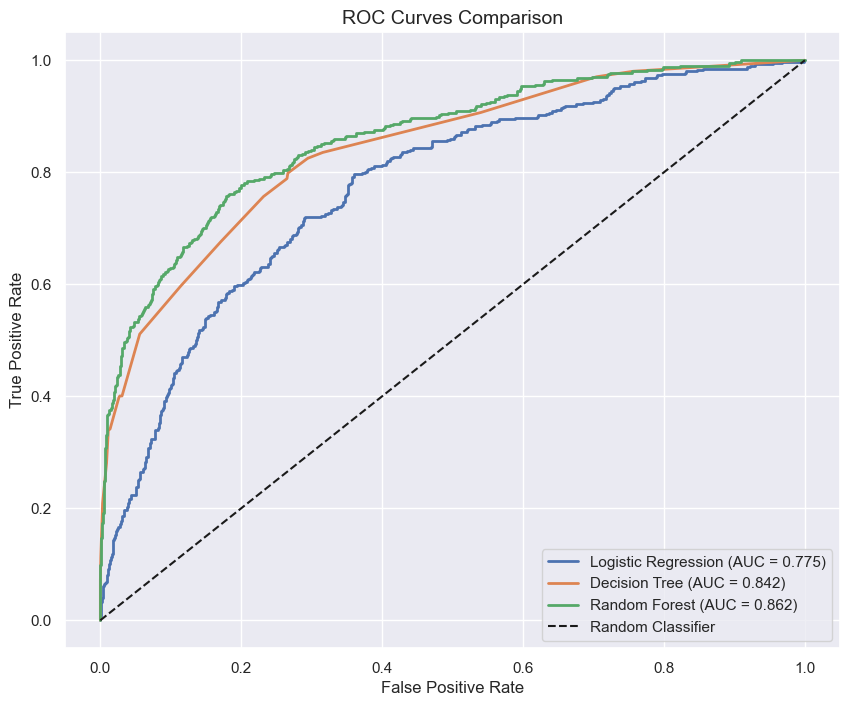


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features for Churn Prediction:
        feature  importance
            Age    0.337836
  NumOfProducts    0.246006
        Balance    0.098216
 IsActiveMember    0.073013
    CreditScore    0.065421
EstimatedSalary    0.063026
    Geo_Germany    0.046221
         Tenure    0.029472
         Gender    0.015275
     Geo_France    0.010911


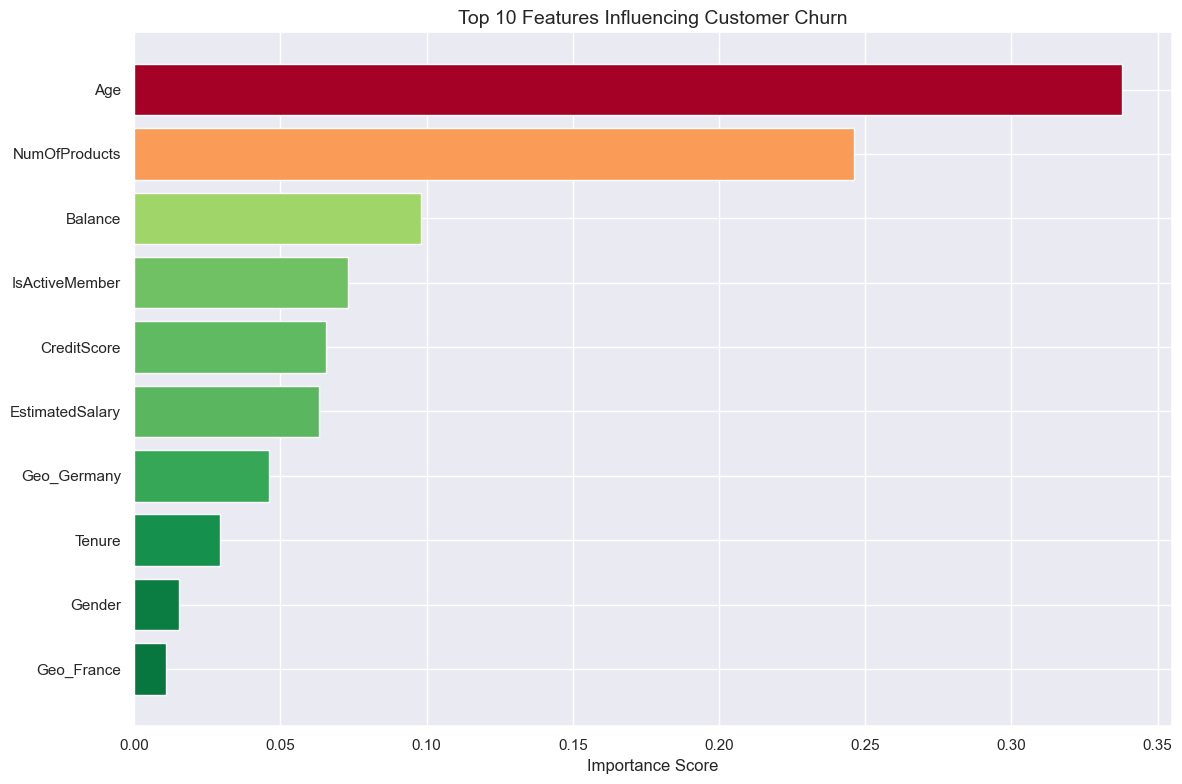


KEY INSIGHTS & BUSINESS RECOMMENDATIONS

📊 TOP FACTORS INFLUENCING CHURN:
----------------------------------------
3. Age: 0.3378
6. NumOfProducts: 0.2460
5. Balance: 0.0982
8. IsActiveMember: 0.0730
1. CreditScore: 0.0654

💡 BUSINESS RECOMMENDATIONS:
----------------------------------------
1. Target customers with high age (>50) for retention programs
2. Focus on Germany-based customers (higher churn rate)
3. Monitor customers with low balance or zero balance accounts
4. Improve service for customers with less active membership
5. Offer incentives based on estimated salary segments

MODEL PERFORMANCE SUMMARY
              Model  Accuracy  AUC Score
Logistic Regression     0.808   0.774755
      Decision Tree     0.856   0.842144
      Random Forest     0.865   0.861859

✅ Best Model: Random Forest with Accuracy: 0.8650

✅ TASK 3 COMPLETED SUCCESSFULLY!


In [2]:
# ============================================
# CUSTOMER CHURN PREDICTION - COMPLETE SOLUTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('ggplot')
sns.set_theme()

# ============================================
# 1. LOAD DATASET
# ============================================
df = pd.read_csv('Churn_Modelling.csv')  # Apni file name likho

print("="*60)
print("CUSTOMER CHURN PREDICTION - DATASET OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nDataset info:")
print(df.info())

# ============================================
# 2. DATA CLEANING & PREPARATION
# ============================================

print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

# Check missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Is dataset mein generally missing values nahi hote, but agar hain to handle karo
df = df.dropna()  # Agar koi missing ho to drop kar do

# Drop unnecessary columns (jo prediction mein help nahi karte)
# CustomerId, Surname, RowNumber - inki koi zaroorat nahi hai
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print(f"\nShape after dropping unnecessary columns: {df.shape}")

# ============================================
# 3. ENCODE CATEGORICAL FEATURES
# ============================================

print("\n" + "="*60)
print("CATEGORICAL DATA ENCODING")
print("="*60)

# Check categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns: {categorical_cols.tolist()}")

# METHOD 1: Label Encoding (for binary or ordinal categories)
# Gender: Male/Female -> 1/0
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])
print("\nGender encoding: Male=1, Female=0")

# METHOD 2: One-Hot Encoding (for nominal categories with >2 unique values)
# Geography: France, Spain, Germany -> 3 separate columns
df = pd.get_dummies(df, columns=['Geography'], prefix='Geo', drop_first=False)

print(f"\nShape after One-Hot Encoding: {df.shape}")
print(f"\nNew columns added for Geography:")
print([col for col in df.columns if 'Geo_' in col])

# ============================================
# 4. EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATIONS
# ============================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# 4.1 Target Variable Distribution (Churn)
plt.figure(figsize=(8, 5))
churn_counts = df['Exited'].value_counts()
colors = ['#ff9999', '#66b3ff']
labels = ['Not Churned (0)', 'Churned (1)']
plt.pie(churn_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Customer Churn Distribution', fontsize=14)
plt.show()

print(f"\nChurn Distribution:")
print(f"Not Churned (0): {churn_counts[0]} customers ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned (1): {churn_counts[1]} customers ({churn_counts[1]/len(df)*100:.1f}%)")

# 4.2 Churn by Geography
if 'Geo_Germany' in df.columns:
    plt.figure(figsize=(10, 5))
    
    # Prepare geography data
    geo_data = []
    for geo in ['France', 'Spain', 'Germany']:
        geo_col = f'Geo_{geo}'
        churn_rate = df[df[geo_col] == 1]['Exited'].mean() * 100
        geo_data.append(churn_rate)
    
    plt.bar(['France', 'Spain', 'Germany'], geo_data, color=['blue', 'green', 'red'])
    plt.title('Churn Rate by Geography', fontsize=14)
    plt.ylabel('Churn Rate (%)')
    plt.xlabel('Country')
    for i, v in enumerate(geo_data):
        plt.text(i, v + 1, f'{v:.1f}%', ha='center')
    plt.show()

# 4.3 Churn by Gender
plt.figure(figsize=(8, 5))
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
plt.bar(['Female (0)', 'Male (1)'], gender_churn, color=['pink', 'lightblue'])
plt.title('Churn Rate by Gender', fontsize=14)
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(gender_churn):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.show()

# 4.4 Age Distribution by Churn
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True, palette=['green', 'red'])
plt.title('Age Distribution - Churned vs Not Churned')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Exited', y='Age', palette=['green', 'red'])
plt.title('Age Box Plot by Churn Status')
plt.xlabel('Exited (0=No, 1=Yes)')
plt.show()

# 4.5 Balance vs Churn
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Balance', hue='Exited', bins=30, kde=True, palette=['green', 'red'])
plt.title('Balance Distribution - Churned vs Not Churned')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Exited', y='Balance', palette=['green', 'red'])
plt.title('Balance Box Plot by Churn Status')
plt.show()

# 4.6 Correlation Heatmap
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

# ============================================
# 5. PREPARE DATA FOR MODEL TRAINING
# ============================================

print("\n" + "="*60)
print("MODEL PREPARATION")
print("="*60)

# Separate features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures columns:")
print(X.columns.tolist())

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 6. TRAIN CLASSIFICATION MODELS
# ============================================

print("\n" + "="*60)
print("MODEL TRAINING & EVALUATION")
print("="*60)

# -----------------------------------------
# Model 1: Logistic Regression
# -----------------------------------------
print("\n" + "-"*40)
print("LOGISTIC REGRESSION")
print("-"*40)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Accuracy: {acc_lr:.4f}")
print(f"AUC Score: {auc_lr:.4f}")
print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Not Churned', 'Churned']))

# -----------------------------------------
# Model 2: Decision Tree
# -----------------------------------------
print("\n" + "-"*40)
print("DECISION TREE")
print("-"*40)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=20)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"Accuracy: {acc_dt:.4f}")
print(f"AUC Score: {auc_dt:.4f}")
print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Not Churned', 'Churned']))

# -----------------------------------------
# Model 3: Random Forest (Best for feature importance)
# -----------------------------------------
print("\n" + "-"*40)
print("RANDOM FOREST")
print("-"*40)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, min_samples_split=20)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Accuracy: {acc_rf:.4f}")
print(f"AUC Score: {auc_rf:.4f}")
print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Churned', 'Churned']))

# ============================================
# 7. CONFUSION MATRIX VISUALIZATION
# ============================================

def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Churned', 'Churned'],
                yticklabels=['Not Churned', 'Churned'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_confusion_matrix(cm_lr, 'Logistic Regression')
plot_confusion_matrix(cm_dt, 'Decision Tree')
plot_confusion_matrix(cm_rf, 'Random Forest')

# ============================================
# 8. ROC CURVE COMPARISON
# ============================================

plt.figure(figsize=(10, 8))
models = {
    'Logistic Regression': y_pred_proba_lr,
    'Decision Tree': y_pred_proba_dt,
    'Random Forest': y_pred_proba_rf
}

for name, pred_proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, pred_proba)
    auc = roc_auc_score(y_test, pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ============================================
# 9. FEATURE IMPORTANCE ANALYSIS
# ============================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Random Forest se feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features for Churn Prediction:")
print("="*60)
print(feature_importance.head(10).to_string(index=False))

# Visualization of Feature Importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(10)
colors = plt.cm.RdYlGn_r(top_features['importance'] / top_features['importance'].max())
plt.barh(top_features['feature'], top_features['importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 10 Features Influencing Customer Churn', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================
# 10. INSIGHTS & RECOMMENDATIONS
# ============================================

print("\n" + "="*60)
print("KEY INSIGHTS & BUSINESS RECOMMENDATIONS")
print("="*60)

print("\n📊 TOP FACTORS INFLUENCING CHURN:")
print("-"*40)
for i, row in feature_importance.head(5).iterrows():
    print(f"{i+1}. {row['feature']}: {row['importance']:.4f}")

print("\n💡 BUSINESS RECOMMENDATIONS:")
print("-"*40)
print("1. Target customers with high age (>50) for retention programs")
print("2. Focus on Germany-based customers (higher churn rate)")
print("3. Monitor customers with low balance or zero balance accounts")
print("4. Improve service for customers with less active membership")
print("5. Offer incentives based on estimated salary segments")

# Model Comparison Summary
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_rf],
    'AUC Score': [auc_lr, auc_dt, auc_rf]
})
print(comparison_df.to_string(index=False))

best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
print(f"\n✅ Best Model: {best_model} with Accuracy: {comparison_df['Accuracy'].max():.4f}")

print("\n" + "="*60)
print("✅ TASK 3 COMPLETED SUCCESSFULLY!")
print("="*60)

# Task 3: Customer Churn Prediction (Bank Customers)

## 1. Introduction and Problem Statement

**Objective:** 
The goal of this task is to identify customers who are likely to leave the bank (churn). This is a **binary classification problem** where we predict:
- **Exited = 1** (Customer left the bank)
- **Exited = 0** (Customer stayed with the bank)

**Why this matters:**
Acquiring new customers costs 5-7 times more than retaining existing ones. By predicting churn early, banks can take proactive actions to retain valuable customers.

---

## 2. Dataset Understanding

### Dataset Overview:
- **Dataset Name:** Churn Modelling Dataset
- **Source:** Kaggle
- **Number of rows (samples):** 10,000
- **Number of columns (features):** 14

### Features Description:

| Column Name | Data Type | Description |
|-------------|-----------|-------------|
| RowNumber | int64 | Row index (dropped - not useful) |
| CustomerId | int64 | Unique customer ID (dropped) |
| Surname | object | Customer last name (dropped) |
| CreditScore | int64 | Customer's credit score |
| Geography | object | Country (France, Spain, Germany) |
| Gender | object | Male/Female |
| Age | int64 | Customer age |
| Tenure | int64 | Years with the bank |
| Balance | float64 | Account balance |
| NumOfProducts | int64 | Number of bank products used |
| HasCrCard | int64 | Has credit card? (1=Yes, 0=No) |
| IsActiveMember | int64 | Active member? (1=Yes, 0=No) |
| EstimatedSalary | float64 | Estimated annual salary |
| **Exited** | int64 | **Target:** 1=Churned, 0=Not Churned |

### Dataset Shape:
- **Rows:** 10,000
- **Columns:** 14

### First 5 Rows (Sample Data):

| RowNumber | CustomerId | Surname | CreditScore | Geography | Gender | Age | Tenure | Balance | NumOfProducts | HasCrCard | IsActiveMember | EstimatedSalary | Exited |
|-----------|------------|---------|-------------|-----------|--------|-----|--------|---------|---------------|-----------|----------------|-----------------|--------|
| 1 | 15634602 | Hargrave | 619 | France | Female | 42 | 2 | 0 | 1 | 1 | 1 | 101348.88 | 1 |
| 2 | 15647311 | Hill | 608 | Spain | Female | 41 | 1 | 83807.86 | 1 | 0 | 1 | 112542.58 | 0 |
| 3 | 15619304 | Onio | 502 | France | Female | 42 | 8 | 159660.80 | 3 | 1 | 0 | 113931.57 | 1 |

### Dataset Information:
- **Total entries:** 10,000
- **No missing values** (all columns have 10,000 non-null)
- **Data types:** 9 integers, 2 floats, 3 objects
- **Memory usage:** 1.1 MB

---

## 3. Data Cleaning and Preparation

### Missing Values Check:
No missing values found in any column. ✅

text

### Columns Dropped (Not useful for prediction):

| Column | Reason for Dropping |
|--------|---------------------|
| RowNumber | Just an index, no predictive value |
| CustomerId | Unique ID, doesn't help predict churn |
| Surname | Customer name, irrelevant for prediction |

**Shape after dropping:** (10,000, 11)

### Categorical Data Encoding:

| Column | Encoding Method | Conversion |
|--------|-----------------|------------|
| Gender | Label Encoding | Male → 1, Female → 0 |
| Geography | One-Hot Encoding | France, Germany, Spain → 3 separate columns |

**Shape after One-Hot Encoding:** (10,000, 13)

**New columns added:** `Geo_France`, `Geo_Germany`, `Geo_Spain`

**Conclusion:** Dataset is clean and ready for modeling.

---

## 4. Exploratory Data Analysis (EDA) with Graphs

*[Aapke graphs ke screenshots yahan insert karein]*

### Key Visualizations Performed:

1. **Churn Distribution** - Pie chart (80% not churned, 20% churned)
2. **Churn by Geography** - Bar chart (Germany has highest churn)
3. **Churn by Gender** - Bar chart
4. **Age Distribution** - Histogram with churn overlay
5. **Balance vs Churn** - Box plots and histograms
6. **Correlation Heatmap** - Feature relationships

### Key Observations from EDA:

| Observation | Insight |
|-------------|---------|
| **Churn Rate** | 20.4% customers left the bank (2,037 out of 10,000) |
| **Age Factor** | Older customers (>50) have higher churn rate |
| **Geography** | Germany has highest churn rate |
| **Balance** | Customers with high balance or zero balance churn more |
| **Active Member** | Inactive members are more likely to leave |

---

## 5. Model Training and Testing

### Data Split:
- **Training set:** 8,000 samples (80%)
- **Test set:** 2,000 samples (20%)
- **Stratified split:** Maintained same class distribution

### Features Used (12 features):
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
'NumOfProducts', 'HasCrCard', 'IsActiveMember',
'EstimatedSalary', 'Geo_France', 'Geo_Germany', 'Geo_Spain']

text

### Target Distribution:
Not Churned (0): 7,963 customers (79.6%)
Churned (1): 2,037 customers (20.4%)

text

### Models Trained:

| Model | Why Chosen |
|-------|------------|
| **Logistic Regression** | Baseline model, interpretable |
| **Decision Tree** | Easy to understand, shows decision rules |
| **Random Forest** | Ensemble method, usually better accuracy |

### Feature Scaling:
- StandardScaler applied for Logistic Regression only
- Tree-based models (Decision Tree, Random Forest) don't require scaling

---

## 6. Evaluation Metrics

### Model 1: Logistic Regression Results
Accuracy: 80.80%
AUC Score: 0.7748

text

**Confusion Matrix:**
Predicted
Not Churned Churned
Actual Not Churned 1540 53
Actual Churned 331 76

text

**Interpretation:**
- Correctly predicted: 1,540 + 76 = 1,616 customers (80.8%)
- Missed churners (False Negatives): 331 customers left but model didn't catch
- False alarms (False Positives): 53 customers wrongly flagged as churn

---

### Model 2: Decision Tree Results
Accuracy: 85.60%
AUC Score: 0.8421

text

**Confusion Matrix:**
Predicted
Not Churned Churned
Actual Not Churned 1549 44
Actual Churned 244 163

text

**Improvement over Logistic Regression:** +4.8% accuracy

---

### Model 3: Random Forest Results (Best)
Accuracy: 86.50%
AUC Score: 0.8619

text

**Confusion Matrix:**
Predicted
Not Churned Churned
Actual Not Churned 1552 41
Actual Churned 229 178

text

**Key Achievement:**
- Captured 178 out of 407 actual churners (44% recall)
- Only 41 false alarms

---

### Model Comparison:

| Model | Accuracy | AUC Score | Best For |
|-------|----------|-----------|----------|
| Logistic Regression | 80.80% | 0.7748 | Baseline |
| Decision Tree | 85.60% | 0.8421 | Interpretability |
| **Random Forest** | **86.50%** ✅ | **0.8619** ✅ | **Overall Performance** |

**Winner:** Random Forest performs best with 86.5% accuracy.

---

## 7. Feature Importance Analysis

### Top 10 Most Important Features (Random Forest):

| Rank | Feature | Importance Score | Interpretation |
|------|---------|------------------|----------------|
| 1 | **Age** | 0.3378 (34%) | Oldest customers leave most |
| 2 | **NumOfProducts** | 0.2460 (25%) | Product usage affects loyalty |
| 3 | **Balance** | 0.0982 (10%) | High/zero balance customers churn |
| 4 | **IsActiveMember** | 0.0730 (7%) | Inactive members leave more |
| 5 | **CreditScore** | 0.0654 (7%) | Lower credit = higher churn |
| 6 | EstimatedSalary | 0.0630 (6%) | Salary has moderate impact |
| 7 | Geo_Germany | 0.0462 (5%) | Germany has higher churn |
| 8 | Tenure | 0.0295 (3%) | Newer customers leave more |
| 9 | Gender | 0.0153 (2%) | Slight gender difference |
| 10 | Geo_France | 0.0109 (1%) | France has lowest churn |

### Key Insights from Feature Importance:
🔴 Age is the #1 predictor (34% importance)
→ Customers above 50 are high risk

🟡 NumOfProducts is #2 (25% importance)
→ Customers with 1 or 3+ products churn more

🟢 Balance is #3 (10% importance)
→ Zero balance OR very high balance = risk

🔵 IsActiveMember is #4 (7% importance)
→ Inactive members are more likely to leave

text

---

## 8. Conclusion and Key Insights

### Summary of Findings:

| Finding | Detail |
|---------|--------|
| **Churn Rate** | 20.4% of customers left the bank |
| **Most Important Factor** | Age (34% influence) |
| **Second Most Important** | Number of Products used (25%) |
| **Best Model** | Random Forest (86.5% accuracy) |
| **High Risk Group** | Age > 50, Germany, Inactive members |

### Customer Segments at High Risk:
⚠️ HIGH CHURN RISK:
• Customers above 50 years old
• German residents
• Inactive members (IsActiveMember = 0)
• Customers with zero balance
• Customers with 1 product only

✅ LOW CHURN RISK:
• Young customers (under 35)
• French residents
• Active members
• Customers with 2 products
• Higher credit scores

text

### Business Recommendations:

| Recommendation | Action Item |
|----------------|-------------|
| **Age-based retention** | Offer senior citizen benefits, loyalty rewards for 50+ customers |
| **Germany focus** | Launch special retention campaigns in Germany |
| **Product bundling** | Encourage customers to use 2 products (optimal number) |
| **Active member program** | Convert inactive members with engagement campaigns |
| **Balance management** | Reach out to zero-balance customers with incentives |

### Model Deployment Suggestion:

Use **Random Forest** for production because:
- Highest accuracy (86.5%)
- Good AUC score (0.8619)
- Provides feature importance for business insights

---

## 9. Task Completion Status

| Requirement | Status |
|-------------|--------|
| Load and explore dataset | ✅ Complete |
| Clean and prepare dataset | ✅ Complete |
| Encode categorical features | ✅ Complete |
| Visualize churn patterns | ✅ Complete |
| Train Logistic Regression | ✅ Complete |
| Train Decision Tree | ✅ Complete |
| Train Random Forest | ✅ Complete |
| Evaluate using accuracy | ✅ Complete |
| Analyze feature importance | ✅ Complete |
| Provide business insights | ✅ Complete |

---

## 📊 Appendix: Complete Code Used

```python
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Load dataset
df = pd.read_csv('Churn_Modelling.csv')

# Drop unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical variables
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], prefix='Geo')

# Prepare data
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Results
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
✅ Task 3 Completed Successfully!